In [1]:
import pandas as pd
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import sys
import os

%load_ext autoreload
%autoreload 2

# 現在のフォルダの「1つ上の階層（../）」をシステムのパスに追加する
sys.path.append(os.path.abspath(".."))

#作成したモジュールをインポート
from src.data_prep import *


### データの読み込みとフィルタリング

In [ ]:
#ペアIDをはじめに付与するバージョン
import pandas as pd
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import sys
import os

%load_ext autoreload
%autoreload 2

# 現在のフォルダの「1つ上の階層（../）」をシステムのパスに追加する
sys.path.append(os.path.abspath(".."))

#作成したモジュールをインポート
from src.data_prep import *

df = load_trajectory_data()
df_clean_p = remove_flicker_noise(df, col='Preceding', threshold=10)
df_clean = remove_flicker_noise(df_clean_p, col='Lane_ID', threshold=10) 

# ① ペアID付与
df_with_pairs = give_pair_id(df_clean)

# ② モードID付与
df_with_mode = give_mode_id_with_pair_id(df_with_pairs, df)

# ③ 追従していない行を除外 追従している車両のみのデータが完成
df_valid = filter_valid_pairs(df_with_mode)

# ④ 車線フィルタ（Lanes 2, 3, 4のみ）
df_lane = filter_lane_with_pair_id(df_valid)

# ⑤ モードフィルタ
df_mode = filter_mode_with_pair_id(df_lane)

# ⑥ 追従時間フィルタ
df_duration = filter_duration_with_pair_id(df_mode)

# ⑧ カットオフウィンドウ
df_cutoff = apply_cutoff_with_pair_id(df_duration)



# ⑦ 加速度フィルタ
df_final = filter_acceleration_with_pair_id(df_cutoff).copy()


# 最終結果の確認
print(f"\n===最終結果===")
print(f"行数: {len(df_final):,}")
print(f"ペア数: {df_final['pair_id'].nunique():,}")
assign_and_count_pair_type_with_pair_id(df_final)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
(4566387, 19)
フリッカリング除去完了
補正されたブロック数: 671
行数: 4,566,387
フリッカリング除去完了
補正されたブロック数: 142
行数: 4,566,387
モードID別ペア数:
mode_id
1.0    12337
2.0      438
3.0      549
4.0       42
5.0      461
dtype: int64
フィルタ前の行数: 4,566,387
フィルタ後の行数: 4,359,245
除外された行数: 207,142

ペア数: 13,827
フィルタ前: 4,359,245行
フィルタ後: 2,338,830行
除外された行数: 2,020,415行

車線の分布:
Lane_ID
2.0    800339
3.0    689350
4.0    849141
Name: count, dtype: int64
フィルタ前のペア数: 5,780
フィルタ後のペア数: 5,666
除外されたペア数: 114

モードID別ペア数:
mode_id
1.0    5067
2.0     237
3.0     326
4.0      36
dtype: int64
フィルタ前のペア数: 5,666
フィルタ後のペア数: 1,562
除外されたペア数: 4,104

フィルタ前の行数: 2,335,438
フィルタ後の行数: 1,483,054
カットオフ前の行数: 1,483,054
カットオフ後の行数: 1,170,654
除外された行数: 312,400

カットオフ前のペア数: 1,562
カットオフ後のペア数: 1,562
閾値: 1.0 m/s² = 3.2808 feet/s²

フィルタ前の行数: 1,170,654
フィルタ後の行数: 879,140
除外された行数: 291,514

フィルタ前のペア数: 1,562
フィルタ後のペア数: 1,562

===最終結果===
行数: 879,140
ペア数: 1,562
追従ペア数:
pair_type
C-C    1443
C-T   

,Vehicle_ID,Frame_ID,Total_Frames,Global_Time,Local_X,Local_Y,Global_X,Global_Y,v_Length,v_Width,...,Preceding,Following,Space_Headway,Time_Headway,time_period,pair_id,leader_class,ego_class,mode_id,pair_type
100,11,157,864,1113433150600,15.236,130.989,6042830.240,2133199.574,17.3,8.4,...,1.0,0,43.76,5.83,1,17.0,2.0,2,1.0,C-C
101,11,158,864,1113433150700,15.212,131.739,6042830.123,2133200.315,17.3,8.4,...,1.0,0,44.06,5.87,1,17.0,2.0,2,1.0,C-C
102,11,159,864,1113433150800,15.188,132.489,6042830.006,2133201.056,17.3,8.4,...,1.0,0,44.36,5.91,1,17.0,2.0,2,1.0,C-C
103,11,160,864,1113433150900,15.163,133.239,6042829.889,2133201.797,17.3,8.4,...,1.0,0,44.66,5.95,1,17.0,2.0,2,1.0,C-C
104,11,161,864,1113433151000,15.139,133.990,6042829.772,2133202.539,17.3,8.4,...,1.0,0,44.96,5.99,1,17.0,2.0,2,1.0,C-C
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1482947,3006,2950,828,1113437859900,42.358,1389.949,6042683.839,2134451.291,15.8,6.9,...,479.0,491,31.61,2.64,3,20091.0,2.0,2,1.0,C-C
1482948,3006,2951,828,1113437860000,42.352,1391.149,6042683.641,2134452.475,15.8,6.9,...,479.0,491,31.91,2.66,3,20091.0,2.0,2,1.0,C-C
1482949,3006,2952,828,1113437860100,42.345,1392.350,6042683.443,2134453.658,15.8,6.9,...,479.0,491,32.19,2.69,3,20091.0,2.0,2,1.0,C-C
1482950,3006,2953,828,1113437860200,42.340,1393.544,6042683.246,2134454.842,15.8,6.9,...,479.0,491,32.49,2.71,3,20091.0,2.0,2,1.0,C-C


### フィルタリングの順序をランダムに変えてみる

In [ ]:
#ペアIDを使わないバージョン
import pandas as pd
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import sys
import os

%load_ext autoreload
%autoreload 2

# 現在のフォルダの「1つ上の階層（../）」をシステムのパスに追加する
sys.path.append(os.path.abspath(".."))

#作成したモジュールをインポート
from src.data_prep import *

# 元のgive_pair_idは時間の連続性を一切チェックしないため、
# 挙動を厳密に一致させるためmax_gap_framesを無効化しておく
LARGE_GAP_1 =5
LARGE_GAP_2 = 999999999


df = load_trajectory_data()
df_clean_p = remove_flicker_noise(df, col='Preceding', threshold=10)
df_clean = remove_flicker_noise(df_clean_p, col='Lane_ID', threshold=10)

# ① モードID付与（pair_id不要）
df_with_mode = give_mode_id_rows(df_clean, df)

# ② 追従していない行を除外
df_valid = filter_valid_rows(df_with_mode)

# ③ 車線フィルタ
df_lane = filter_lane_rows(df_valid)

# ④ モードフィルタ
df_mode = filter_mode_rows(df_lane)

# ⑤ 追従時間フィルタ
df_duration = filter_duration_rows(df_mode, min_duration=60, max_gap_frames=LARGE_GAP_1)

# ⑥ カットオフウィンドウ
df_cutoff = apply_cutoff_rows(df_duration, cutoff=10, max_gap_frames=LARGE_GAP_1)

# ⑦ 加速度フィルタ
df_final = filter_acceleration_rows(df_cutoff, max_acc=1.0).copy()


# 最終結果の確認
print(f"\n===最終結果===")
print(f"行数: {len(df_final):,}")

df_final = assign_pair_type(df_final)
final_pair_type_counts = count_pair_type(df_final, max_gap_frames=LARGE_GAP_2)

print(f"ペア数: {final_pair_type_counts.sum():,}")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
(4566387, 19)
フリッカリング除去完了
補正されたブロック数: 671
行数: 4,566,387
フリッカリング除去完了
補正されたブロック数: 142
行数: 4,566,387
[give_mode_id_rows] mode_id付与完了: 4,566,387行
mode_id
1.0    4020068
2.0     146002
3.0     142547
4.0      15652
5.0      34976
NaN     207142
Name: count, dtype: int64
[filter_valid_rows] フィルタ前: 4,566,387行 → フィルタ後: 4,359,245行 (除外 207,142行)
[filter_lane_rows] フィルタ前: 4,359,245行 → フィルタ後: 2,338,830行 (除外 2,020,415行)
[filter_mode_rows] フィルタ前: 2,338,830行 → フィルタ後: 2,335,438行 (除外 3,392行)
[filter_duration_rows] フィルタ前の行数: 2,335,438 → フィルタ後: 1,487,854 (除外 847,584行)
使い捨てペア数: 5,665 → 60秒以上のペア数: 1,570
[apply_cutoff_rows] カットオフ前の行数: 1,487,854 → カットオフ後: 1,173,854 (除外 314,000行)
使い捨てペア数: 1,570 → カットオフ後も行が残るペア数: 1,570
[filter_acceleration_rows] 閾値: 1.0 m/s² = 3.2808 feet/s²
フィルタ前: 1,173,854行 → フィルタ後: 881,448行 (除外 292,406行)

===最終結果===
行数: 881,448
追従ペア数:
pair_type
C-C    1446
C-T      65
C-M       0
T-T       6
T-C      48


In [ ]:
#行を削除する順番により、データ間の隙間の幅が変わる→許容ギャップ幅を切り変える必要がある
#accフィルタをかけた後の抜けはある程度許容し、一つのつながったLFペアとして扱いたい。
#車線を排除した後、A->B->Aのようになっているデータは別物として扱いたい.

import itertools
import io
import contextlib
import pandas as pd

LARGE_GAP = 10**9 #ギャップを無視
SMALL_GAP = 5 #0.5s分のデータ抜けまで許容

def run_pipeline(df_base, order):
    """
    order: ['valid','lane','mode','duration','cutoff','accel'] の順列の1つ
    df_base: flicker-fix + mode_id付与済みのデータ
    """
    df = df_base
    accel_done = False
    content_filter_done = False  # valid/lane/modeのいずれかが適用済みか
    ambiguous = False #許容ギャップに競合が生じたか

    #パイプライン処理　指定されたorderに従ってフィルタを適用する
    #content_filter_doneは結構ごっそり抜けるタイプのフィルタ
    #accは抜けがあっても一つのつながったLFペアとして扱いたいタイプのフィルタ

    for step in order:
        if step == 'valid':
            df = filter_valid_rows(df)
            content_filter_done = True
        elif step == 'lane':
            df = filter_lane_rows(df)
            content_filter_done = True
        elif step == 'mode':
            df = filter_mode_rows(df)
            content_filter_done = True
        elif step == 'accel':
            df = filter_acceleration_rows(df, max_acc=1.0)
            accel_done = True
        elif step in ('duration', 'cutoff'): #判定に許容幅が関係する
            if accel_done and content_filter_done:#解釈に曖昧さが生れる
                gap, ambiguous = LARGE_GAP, True
            elif accel_done:#加速度フィルタがすでに適用され、細かいく切れが乱立している->大きな空はたぶんないので
                gap = LARGE_GAP
            elif content_filter_done:#
                gap = SMALL_GAP
            else:
                gap = LARGE_GAP
            if step == 'duration':
                df = filter_duration_rows(df, min_duration=60, max_gap_frames=gap)
            else:
                df = apply_cutoff_rows(df, cutoff=10, max_gap_frames=gap)

    gap_final = LARGE_GAP if accel_done else (SMALL_GAP if content_filter_done else LARGE_GAP)
    if accel_done and content_filter_done:
        ambiguous = True

    df = assign_pair_type(df)
    type_counts = count_pair_type(df, max_gap_frames=gap_final)

    result = {
        'order': ' → '.join(order),
        'final_rows': len(df),
        'final_pairs': int(type_counts.sum()),
        'ambiguous': ambiguous,
    }
    for k, v in type_counts.items():
        result[f'type_{k}'] = int(v)
    return result

In [16]:
shuffle_targets = ['valid', 'lane', 'mode', 'duration', 'cutoff', 'accel']  # 6! = 720通り

df = load_trajectory_data()
df_clean_p = remove_flicker_noise(df, col='Preceding', threshold=10)
df_clean = remove_flicker_noise(df_clean_p, col='Lane_ID', threshold=10)
df_base = give_mode_id_rows(df_clean, df)

results = []
for i, perm in enumerate(itertools.permutations(shuffle_targets)):
    with contextlib.redirect_stdout(io.StringIO()):  # 各フィルタの詳細printを抑制
        res = run_pipeline(df_base, list(perm))
    results.append(res)
    if (i + 1) % 50 == 0:
        print(f"{i+1}/720 完了...")

summary_df = pd.DataFrame(results)
summary_df = summary_df.sort_values('final_pairs')

from pathlib import Path

Path('../results').mkdir(parents=True, exist_ok=True)
summary_df.to_csv('../results/filter_order_sweep.csv', index=False)

print(summary_df[['order', 'final_rows', 'final_pairs', 'ambiguous']].to_string(index=False))
print("\n=== ambiguousフラグ別のペア数の分布 ===")
print(summary_df.groupby('ambiguous')['final_pairs'].describe())

(4566387, 19)
フリッカリング除去完了
補正されたブロック数: 671
行数: 4,566,387
フリッカリング除去完了
補正されたブロック数: 142
行数: 4,566,387
[give_mode_id_rows] mode_id付与完了: 4,566,387行
mode_id
1.0    4020068
2.0     146002
3.0     142547
4.0      15652
5.0      34976
NaN     207142
Name: count, dtype: int64
50/720 完了...
100/720 完了...
150/720 完了...
200/720 完了...
250/720 完了...
300/720 完了...
350/720 完了...
400/720 完了...
450/720 完了...
500/720 完了...
550/720 完了...
600/720 完了...
650/720 完了...
700/720 完了...
                                          order  final_rows  final_pairs  ambiguous
valid → mode → lane → cutoff → duration → accel      618649          810       True
valid → mode → cutoff → duration → accel → lane      618649          810       True
valid → mode → cutoff → duration → lane → accel      618649          810       True
cutoff → mode → duration → accel → lane → valid      618649          810       True
cutoff → mode → duration → accel → valid → lane      618649          810       True
valid → mode → cutoff → lane → dura

In [13]:
import time
import itertools
import io
import contextlib

df = load_trajectory_data()
df_clean_p = remove_flicker_noise(df, col='Preceding', threshold=10)
df_clean = remove_flicker_noise(df_clean_p, col='Lane_ID', threshold=10)
df_base = give_mode_id_rows(df_clean, df)

shuffle_targets = ['valid', 'lane', 'mode', 'duration', 'cutoff', 'accel']
sample_perms = list(itertools.permutations(shuffle_targets))[:5]

results = []
start = time.time()

for perm in sample_perms:
    t0 = time.time()
    with contextlib.redirect_stdout(io.StringIO()):
        res = run_pipeline(df_base, list(perm))
    res['elapsed_sec'] = round(time.time() - t0, 2)
    results.append(res)
    print(f"[{res['elapsed_sec']}s] {res['order']}: rows={res['final_rows']:,} pairs={res['final_pairs']:,} {'[要注意]' if res['ambiguous'] else ''}")

total_elapsed = time.time() - start
per_run = total_elapsed / len(sample_perms)
estimated_720 = per_run * 720

print(f"\n5回の合計時間: {total_elapsed:.1f}秒")
print(f"1回あたり平均: {per_run:.2f}秒")
print(f"720回の推定所要時間: 約{estimated_720/60:.1f}分 (約{estimated_720/3600:.2f}時間)")

sample_df = pd.DataFrame(results)
print(sample_df[['order', 'final_rows', 'final_pairs', 'ambiguous', 'elapsed_sec']].to_string(index=False))

(4566387, 19)
フリッカリング除去完了
補正されたブロック数: 671
行数: 4,566,387
フリッカリング除去完了
補正されたブロック数: 142
行数: 4,566,387
[give_mode_id_rows] mode_id付与完了: 4,566,387行
mode_id
1.0    4020068
2.0     146002
3.0     142547
4.0      15652
5.0      34976
NaN     207142
Name: count, dtype: int64
[3.15s] valid → lane → mode → duration → cutoff → accel: rows=881,448 pairs=1,565 [要注意]
[3.35s] valid → lane → mode → duration → accel → cutoff: rows=880,445 pairs=1,565 [要注意]
[3.56s] valid → lane → mode → cutoff → duration → accel: rows=618,649 pairs=810 [要注意]
[3.21s] valid → lane → mode → cutoff → accel → duration: rows=628,435 pairs=824 [要注意]
[3.19s] valid → lane → mode → accel → duration → cutoff: rows=884,763 pairs=1,572 [要注意]

5回の合計時間: 16.5秒
1回あたり平均: 3.29秒
720回の推定所要時間: 約39.5分 (約0.66時間)
                                          order  final_rows  final_pairs  ambiguous  elapsed_sec
valid → lane → mode → duration → cutoff → accel      881448         1565       True         3.15
valid → lane → mode → duration → accel → cu

In [4]:
#改良版

def count_pairs_only(df, max_gap_frames):
    """ペア数だけを軽量に数えるヘルパー"""
    df_paired = make_temp_pair_id(df, max_gap_frames=max_gap_frames)
    return int(df_paired['temp_pair_id'].nunique())


def run_pipeline(df_base, order):
    df = df_base
    accel_done = False
    content_filter_done = False
    ambiguous = False
    step_log = []

    for i, step in enumerate(order):
        rows_before = len(df)
        entry = {'position': i + 1, 'step': step, 'rows_before': rows_before}

        if step == 'valid':
            df = filter_valid_rows(df)
            content_filter_done = True
        elif step == 'lane':
            df = filter_lane_rows(df)
            content_filter_done = True
        elif step == 'mode':
            df = filter_mode_rows(df)
            content_filter_done = True
        elif step == 'accel':
            df = filter_acceleration_rows(df, max_acc=1.0)
            accel_done = True
        elif step in ('duration', 'cutoff'):
            if accel_done and content_filter_done:
                gap, ambiguous = LARGE_GAP, True
            elif accel_done:
                gap = LARGE_GAP
            elif content_filter_done:
                gap = SMALL_GAP
            else:
                gap = LARGE_GAP

            pairs_before = count_pairs_only(df, gap)
            df = filter_duration_rows(df, min_duration=60, max_gap_frames=gap) if step == 'duration' \
                 else apply_cutoff_rows(df, cutoff=10, max_gap_frames=gap)
            pairs_after = count_pairs_only(df, gap)

            entry.update({'pairs_before': pairs_before, 'pairs_after': pairs_after,
                          'pairs_removed': pairs_before - pairs_after, 'gap_used': gap})

        entry['rows_after'] = len(df)
        entry['rows_removed'] = rows_before - entry['rows_after']
        step_log.append(entry)

    gap_final = LARGE_GAP if accel_done else (SMALL_GAP if content_filter_done else LARGE_GAP)
    if accel_done and content_filter_done:
        ambiguous = True

    df = assign_pair_type(df)
    type_counts = count_pair_type(df, max_gap_frames=gap_final)

    result = {
        'order': ' → '.join(order),
        'final_rows': len(df),
        'final_pairs': int(type_counts.sum()),
        'ambiguous': ambiguous,
        'step_log': step_log,
    }
    for k, v in type_counts.items():
        result[f'type_{k}'] = int(v)
    return result

In [6]:
def flatten_logs(results):
    rows = []
    for res in results:
        for entry in res['step_log']:
            rows.append({'order': res['order'], **entry})
    return pd.DataFrame(rows)

In [ ]:
import itertools
import io
import contextlib

# ① 準備データ(前と同じ)
df = load_trajectory_data()
df_clean_p = remove_flicker_noise(df, col='Preceding', threshold=10)
df_clean = remove_flicker_noise(df_clean_p, col='Lane_ID', threshold=10)
df_base = give_mode_id_rows(df_clean, df)

# ② 改良版run_pipelineで720パターン(または一部)を実行し、resultsに溜める
shuffle_targets = ['valid', 'lane', 'mode', 'duration', 'cutoff', 'accel']

results = []
for i, perm in enumerate(itertools.permutations(shuffle_targets)):
    with contextlib.redirect_stdout(io.StringIO()):
        res = run_pipeline(df_base, list(perm))  # ← 改良版を使う
    results.append(res)
    if (i + 1) % 50 == 0:
        print(f"{i+1}/720 完了...")

# ③ 各結果に入っているstep_log(ステップごとの詳細)を展開する
log_df = flatten_logs(results)

# ④ 分析クエリを実行
print(log_df.groupby('step')['rows_removed'].describe())
print(log_df[log_df['step']=='duration'].groupby('position')['pairs_removed'].describe())

In [7]:
# ステップごとの平均減少行数（順序によらず）
log_df.groupby('step')['rows_removed'].describe()

# durationフィルタが何番目に来たかで、減少ペア数がどう変わるか
log_df[log_df['step']=='duration'].groupby('position')['pairs_removed'].describe()

NameError: name 'log_df' is not defined

In [10]:
import itertools
import io
import contextlib
import time


# ① 準備データ(前と同じ)
df = load_trajectory_data()
df_clean_p = remove_flicker_noise(df, col='Preceding', threshold=10)
df_clean = remove_flicker_noise(df_clean_p, col='Lane_ID', threshold=10)
df_base = give_mode_id_rows(df_clean, df)


LARGE_GAP = 10**9 #ギャップを無視
SMALL_GAP = 5 #0.5s分のデータ抜けまで許容


shuffle_targets = ['valid', 'lane', 'mode', 'duration', 'cutoff', 'accel']
sample_perms = list(itertools.permutations(shuffle_targets))[:5]

results = []
start = time.time()

for perm in sample_perms:
    t0 = time.time()
    with contextlib.redirect_stdout(io.StringIO()):
        res = run_pipeline(df_base, list(perm))
    elapsed = round(time.time() - t0, 2)
    res['elapsed_sec'] = elapsed
    results.append(res)
    print(f"[{elapsed}s] {res['order']}: rows={res['final_rows']:,} pairs={res['final_pairs']:,} {'[要注意]' if res['ambiguous'] else ''}")

total_elapsed = time.time() - start
per_run = total_elapsed / len(sample_perms)
print(f"\n5回の合計時間: {total_elapsed:.1f}秒 (1回あたり平均: {per_run:.2f}秒)")
print(f"720回の推定所要時間: 約{per_run*720/60:.1f}分")

# step_logの展開・確認
log_df = flatten_logs(results)
print(f"\nlog_dfの行数: {len(log_df):,} (5パターン × 6ステップ = 30行のはず)")
print(log_df[['order', 'position', 'step', 'rows_before', 'rows_after', 'rows_removed',
              'pairs_before', 'pairs_after', 'pairs_removed', 'gap_used']].to_string(index=False))

(4566387, 19)
フリッカリング除去完了
補正されたブロック数: 671
行数: 4,566,387
フリッカリング除去完了
補正されたブロック数: 142
行数: 4,566,387
[give_mode_id_rows] mode_id付与完了: 4,566,387行
mode_id
1.0    4020068
2.0     146002
3.0     142547
4.0      15652
5.0      34976
NaN     207142
Name: count, dtype: int64
[5.63s] valid → lane → mode → duration → cutoff → accel: rows=881,448 pairs=1,565 [要注意]
[4.14s] valid → lane → mode → duration → accel → cutoff: rows=880,445 pairs=1,565 [要注意]
[3.94s] valid → lane → mode → cutoff → duration → accel: rows=618,649 pairs=810 [要注意]
[3.92s] valid → lane → mode → cutoff → accel → duration: rows=628,435 pairs=824 [要注意]
[3.73s] valid → lane → mode → accel → duration → cutoff: rows=884,763 pairs=1,572 [要注意]

5回の合計時間: 21.4秒 (1回あたり平均: 4.27秒)
720回の推定所要時間: 約51.3分

log_dfの行数: 30 (5パターン × 6ステップ = 30行のはず)
                                          order  position     step  rows_before  rows_after  rows_removed  pairs_before  pairs_after  pairs_removed     gap_used
valid → lane → mode → duration → cutoff → ac

### ローパスフィルタの実装

In [2]:
import numpy as np
from scipy.signal import savgol_filter

def smooth_speed(df, window_length=11, polyorder=3, speed_col='v_Vel'):
    """
    車両(Vehicle_ID, time_period)ごとに独立してSavitzky-Golayフィルタをかけ、
    速度の高周波ノイズ(NGSIM特有の階段状の疑似定速パターン)を平滑化する。

    window_length: フィルタ窓の長さ(フレーム数, 奇数)。10Hzサンプリングなので
                    11なら約1.1秒, 21なら約2.1秒の窓になる
    polyorder: 窓内でフィットする多項式の次数(window_length未満である必要がある)
    """
    df = df.sort_values(['time_period', 'Vehicle_ID', 'Global_Time']).copy()

    def _smooth(s):
        if len(s) < window_length:
            return s  # 窓より短い軌跡は平滑化しない
        return pd.Series(
            savgol_filter(s.values, window_length=window_length, polyorder=polyorder),
            index=s.index
        )

    df[f'{speed_col}_smooth'] = df.groupby(['Vehicle_ID', 'time_period'])[speed_col].transform(_smooth)

    return df

In [3]:
def recompute_acceleration(df, speed_col='v_Vel_smooth'):
    """平滑化した速度の差分から加速度を再計算する(ft/s^2)。"""
    df = df.sort_values(['time_period', 'Vehicle_ID', 'Global_Time']).copy()
    g = df.groupby(['Vehicle_ID', 'time_period'])
    dt = g['Global_Time'].diff() / 1000  # ms -> s
    dv = g[speed_col].diff()
    df['v_Acc_recalc'] = dv / dt
    return df

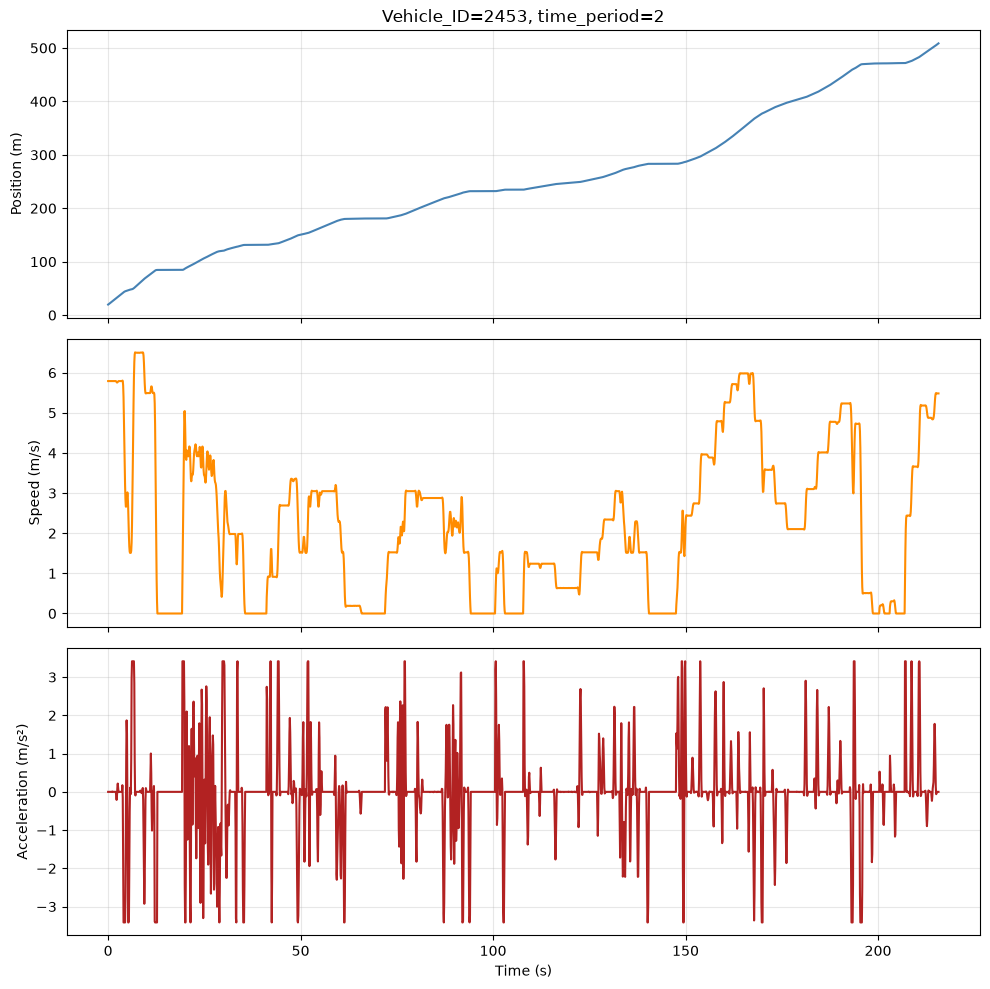

Vehicle_ID=2453, time_period=2, フレーム数=2158


In [11]:
import matplotlib.pyplot as plt

# 適当な車両を選ぶ(ある程度長い軌跡を持つものを選択)
vehicle_id, time_period = (
    df.groupby(['Vehicle_ID', 'time_period'])
      .size()
      .sort_values(ascending=False)
      .index[20]  # 極端に長い/特殊なケースを避けて少しずらして選択
)

sample = df[(df['Vehicle_ID'] == vehicle_id) & (df['time_period'] == time_period)].sort_values('Global_Time')
t_sec = (sample['Global_Time'] - sample['Global_Time'].min()) / 1000

fig, axes = plt.subplots(3, 1, figsize=(10, 10), sharex=True)

axes[0].plot(t_sec, sample['Local_Y'] * 0.3048, color='steelblue')
axes[0].set_ylabel('Position (m)')
axes[0].set_title(f'Vehicle_ID={vehicle_id}, time_period={time_period}')
axes[0].grid(alpha=0.3)

axes[1].plot(t_sec, sample['v_Vel'] * 0.3048, color='darkorange')
axes[1].set_ylabel('Speed (m/s)')
axes[1].grid(alpha=0.3)

axes[2].plot(t_sec, sample['v_Acc'] * 0.3048, color='firebrick')
axes[2].set_ylabel('Acceleration (m/s²)')
axes[2].set_xlabel('Time (s)')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Vehicle_ID={vehicle_id}, time_period={time_period}, フレーム数={len(sample)}")

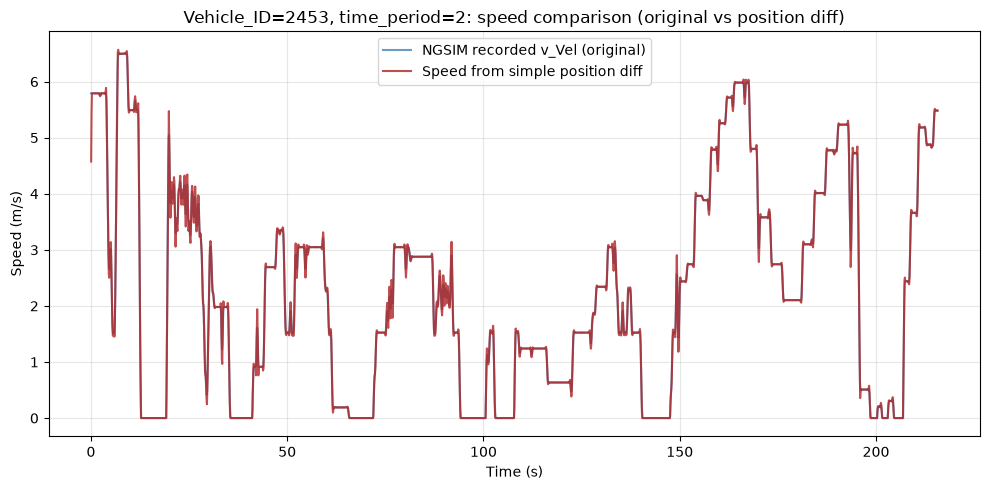

In [13]:
import matplotlib.pyplot as plt
import numpy as np

t0 = sample['Global_Time'].min()
t_sec = (sample['Global_Time'].values - t0) / 1000       # relative time (s) for each frame
position_m = sample['Local_Y'].values * 0.3048           # position (m)
speed_original = sample['v_Vel'].values * 0.3048         # speed recorded by NGSIM (m/s)

# derive speed by simple differencing of position
speed_from_diff = np.diff(position_m) / np.diff(t_sec)
t_mid = (t_sec[:-1] + t_sec[1:]) / 2  # diff represents the interval between two points, so plot at midpoint

plt.figure(figsize=(10, 5))
plt.plot(t_sec, speed_original, label='NGSIM recorded v_Vel (original)', color='steelblue', alpha=0.8)
plt.plot(t_mid, speed_from_diff, label='Speed from simple position diff', color='firebrick', alpha=0.8)
plt.xlabel('Time (s)')
plt.ylabel('Speed (m/s)')
plt.title(f'Vehicle_ID={vehicle_id}, time_period={time_period}: speed comparison (original vs position diff)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

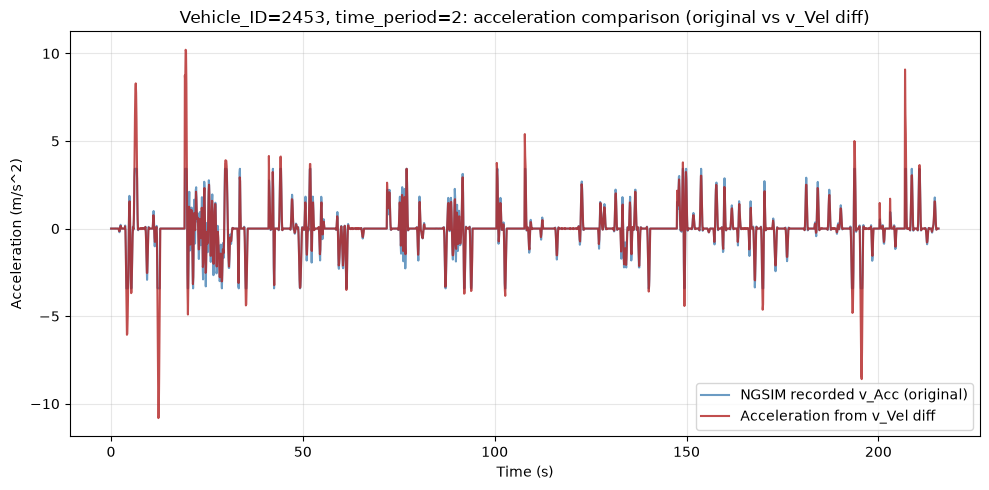

In [14]:
import matplotlib.pyplot as plt
import numpy as np

speed_original_ms = sample['v_Vel'].values * 0.3048
acc_original = sample['v_Acc'].values * 0.3048

# v_Velを差分して加速度を算出
acc_from_diff = np.diff(speed_original_ms) / np.diff(t_sec)
t_mid_acc = (t_sec[:-1] + t_sec[1:]) / 2

plt.figure(figsize=(10, 5))
plt.plot(t_sec, acc_original, label='NGSIM recorded v_Acc (original)', color='steelblue', alpha=0.8)
plt.plot(t_mid_acc, acc_from_diff, label='Acceleration from v_Vel diff', color='firebrick', alpha=0.8)
plt.xlabel('Time (s)')
plt.ylabel('Acceleration (m/s^2)')
plt.title(f'Vehicle_ID={vehicle_id}, time_period={time_period}: acceleration comparison (original vs v_Vel diff)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

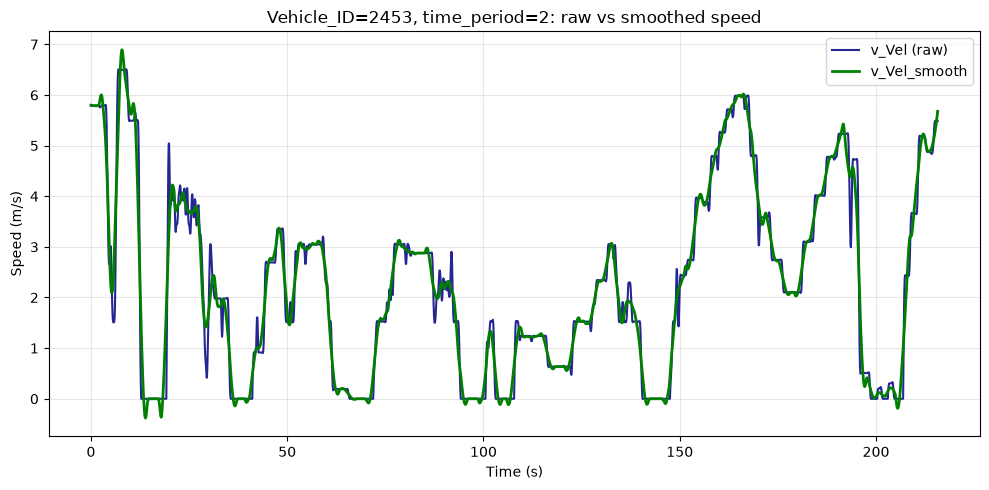

In [24]:
import matplotlib.pyplot as plt

sample_smoothed = smooth_speed(sample, window_length=40, polyorder=3)

plt.figure(figsize=(10, 5))
plt.plot(t_sec, sample['v_Vel'] * 0.3048, label='v_Vel (raw)', color='navy', alpha=0.85)
plt.plot(t_sec, sample_smoothed['v_Vel_smooth'] * 0.3048, label='v_Vel_smooth', color='green', linewidth=2)
plt.xlabel('Time (s)')
plt.ylabel('Speed (m/s)')
plt.title(f'Vehicle_ID={vehicle_id}, time_period={time_period}: raw vs smoothed speed')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

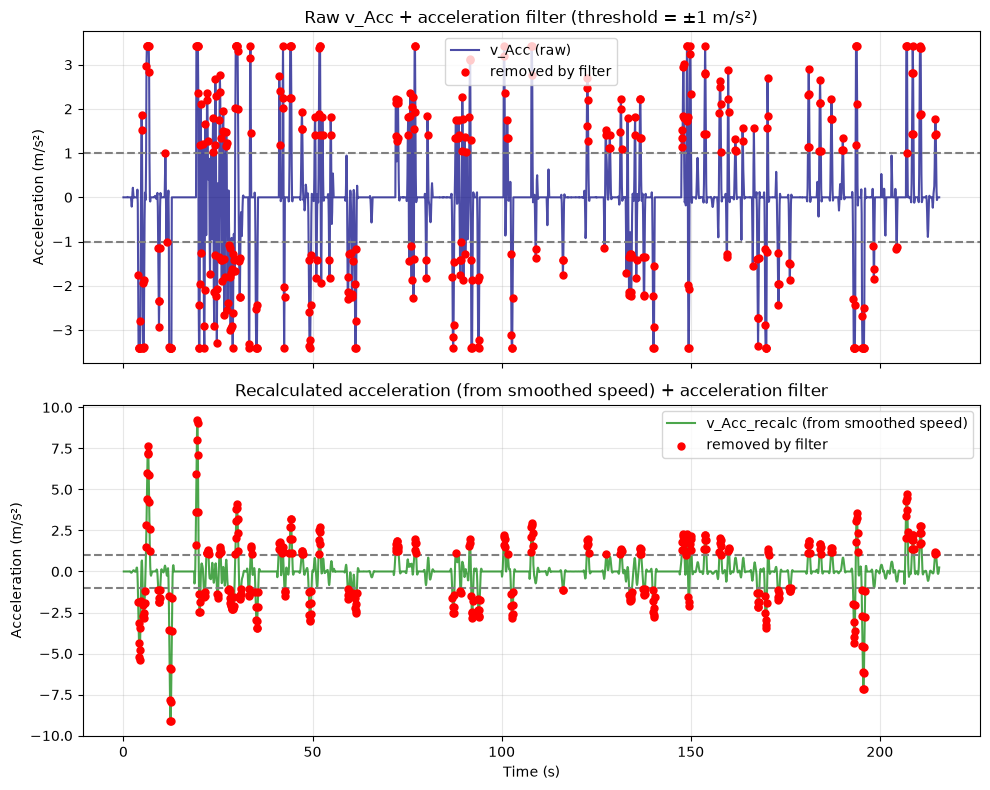

raw v_Acc: removed 415 / 2158 frames (19.2%)
recalculated v_Acc: removed 372 / 2158 frames (17.2%)


In [25]:
import numpy as np
import matplotlib.pyplot as plt

max_acc_ms2 = 1.0

sample_smoothed = smooth_speed(sample, window_length=11, polyorder=3)
sample_smoothed = recompute_acceleration(sample_smoothed, speed_col='v_Vel_smooth')

acc_raw = (sample_smoothed['v_Acc'] * 0.3048).values
acc_recalc = (sample_smoothed['v_Acc_recalc'] * 0.3048).values

removed_raw = np.abs(acc_raw) > max_acc_ms2
removed_recalc = np.abs(acc_recalc) > max_acc_ms2

fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

axes[0].plot(t_sec, acc_raw, color='navy', alpha=0.7, label='v_Acc (raw)')
axes[0].scatter(t_sec[removed_raw], acc_raw[removed_raw], color='red', s=25, zorder=5, label='removed by filter')
axes[0].axhline(max_acc_ms2, color='gray', linestyle='--')
axes[0].axhline(-max_acc_ms2, color='gray', linestyle='--')
axes[0].set_ylabel('Acceleration (m/s²)')
axes[0].set_title('Raw v_Acc + acceleration filter (threshold = ±1 m/s²)')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(t_sec, acc_recalc, color='green', alpha=0.7, label='v_Acc_recalc (from smoothed speed)')
axes[1].scatter(t_sec[removed_recalc], acc_recalc[removed_recalc], color='red', s=25, zorder=5, label='removed by filter')
axes[1].axhline(max_acc_ms2, color='gray', linestyle='--')
axes[1].axhline(-max_acc_ms2, color='gray', linestyle='--')
axes[1].set_ylabel('Acceleration (m/s²)')
axes[1].set_xlabel('Time (s)')
axes[1].set_title('Recalculated acceleration (from smoothed speed) + acceleration filter')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"raw v_Acc: removed {removed_raw.sum()} / {len(sample_smoothed)} frames ({removed_raw.mean()*100:.1f}%)")
print(f"recalculated v_Acc: removed {removed_recalc.sum()} / {len(sample_smoothed)} frames ({removed_recalc.mean()*100:.1f}%)")